In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.__version__

'0.13.2'

In [4]:
sales_df = pd.DataFrame({
    "advertising": [
        10, 15, 20, 25,
        12, 18, 23, 28,
        8, 14, 19, 24,
    ],
    "sales": [
        120, 155, 190, 230,
        110, 150, 185, 215,
        95, 135, 170, 205,
    ],
    "region": [
        "Seoul", "Seoul", "Seoul", "Seoul",
        "Busan", "Busan", "Busan", "Busan",
        "Daejeon", "Daejeon", "Daejeon", "Daejeon",
    ],
    "visitors": [
        850, 1020, 1180, 1350,
        780, 950, 1100, 1280,
        690, 870, 1030, 1200,
    ],
    "channel": [
        "Online", "Offline", "Online", "Offline",
        "Online", "Offline", "Online", "Offline",
        "Online", "Offline", "Online", "Offline",
    ],
})

sales_df

,advertising,sales,region,visitors,channel
0,10,120,Seoul,850,Online
1,15,155,Seoul,1020,Offline
2,20,190,Seoul,1180,Online
3,25,230,Seoul,1350,Offline
4,12,110,Busan,780,Online
5,18,150,Busan,950,Offline
6,23,185,Busan,1100,Online
7,28,215,Busan,1280,Offline
8,8,95,Daejeon,690,Online
9,14,135,Daejeon,870,Offline


- Long-term 데이터
- Wide=form 데이터

## Long-form Data

일반적으로 하나의 열이 하나의 변수 하나의 행이 하나의 관측값을 갖는 구조

In [5]:
long_sales = pd.DataFrame({     # 세 개 도시의 1,2,3,4월의 매출에 대한 데이터
    "month": [
        "Jan", "Jan", "Jan",
        "Feb", "Feb", "Feb",
        "Mar", "Mar", "Mar",
        "Apr", "Apr", "Apr",
    ],
    "region": [
        "Seoul", "Busan", "Daejeon",
        "Seoul", "Busan", "Daejeon",
        "Seoul", "Busan", "Daejeon",
        "Seoul", "Busan", "Daejeon",
    ],
    "sales": [
        120, 100, 90,
        150, 130, 115,
        180, 160, 145,
        210, 190, 175,
    ],
})

long_sales

,month,region,sales
0,Jan,Seoul,120
1,Jan,Busan,100
2,Jan,Daejeon,90
3,Feb,Seoul,150
4,Feb,Busan,130
5,Feb,Daejeon,115
6,Mar,Seoul,180
7,Mar,Busan,160
8,Mar,Daejeon,145
9,Apr,Seoul,210


<Axes: xlabel='month', ylabel='sales'>

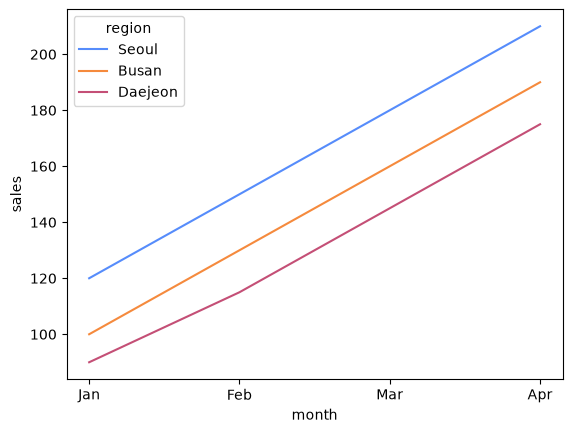

In [6]:
sns.lineplot(    #표 자체를 집어넣은 것
    data=long_sales,
    x='month',
    y='sales',
    hue='region'
)

<Axes: xlabel='month', ylabel='sales'>

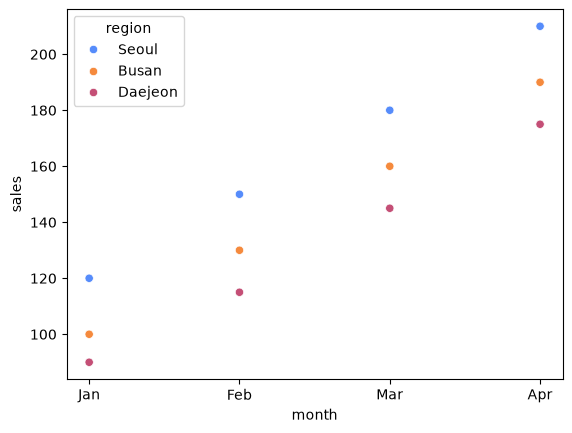

In [7]:
sns.scatterplot(
    data=long_sales,
    x='month',
    y='sales',
    hue='region'
)

# seaborn>최종적으로 출력하기 위해서는 plt.show()를 해주는 게 맞다.

## Wide-form Data

하나의 측정 변수가 여러 열로 펼쳐져 있는 형태

In [8]:
wide_sales = pd.DataFrame(
    {
        "Seoul": [120, 150, 180, 210],
        "Busan": [100, 130, 160, 190],
        "Daejeon": [90, 115, 145, 175],
    },
    index=["Jan", "Feb", "Mar", "Apr"],
)

wide_sales.index.name = "month"

wide_sales

,Seoul,Busan,Daejeon
month,,,
Jan,120,100,90
Feb,150,130,115
Mar,180,160,145
Apr,210,190,175


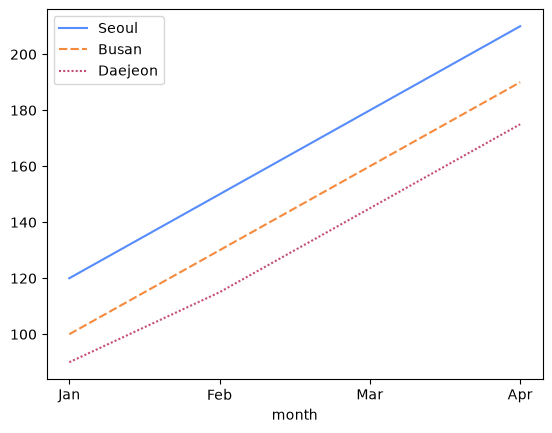

In [9]:
sns.lineplot(data=wide_sales)
plt.show()

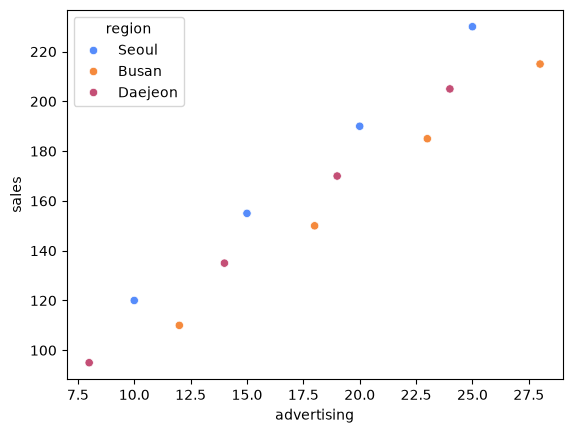

In [11]:
# 광고와 매출의 관계가 어떤지 보고싶다.

sns.scatterplot(
    data=sales_df,
    x='advertising',
    y='sales',
    hue='region'
)
plt.show()

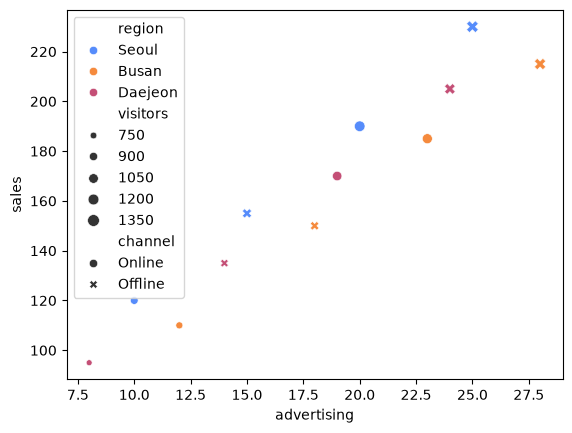

In [14]:
sns.scatterplot(
    data=sales_df,
    x='advertising',
    y='sales',
    hue='region',  #색상으로 구분
    size='visitors', #크기로 구분
    style='channel'   #channel의 구분을 기호로 해줌
)
plt.show()

<Axes: xlabel='advertising', ylabel='sales'>

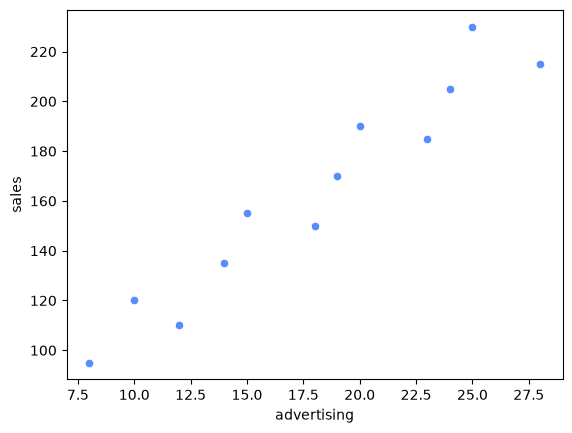

In [16]:
# 그래프 분리하는 법 _ 여러 개의 그래프 그릴 수 있어서 중요함***

sns.scatterplot(
    data=sales_df,
    x='advertising',
    y='sales',
)

# <Axes: xlabel='advertising', ylabel='sales'>
# 무언가 반환이 되고 반환된 데이터의 타입이 axes구나를 알 수 있다

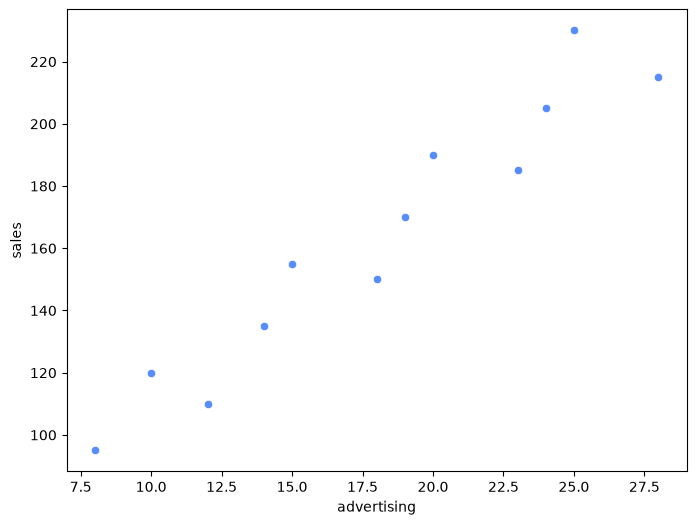

In [18]:
fig,ax=plt.subplots(figsize=(8,6))

sns.scatterplot(
    data=sales_df,
    x='advertising',
    y='sales',
    ax=ax
)

plt.show()


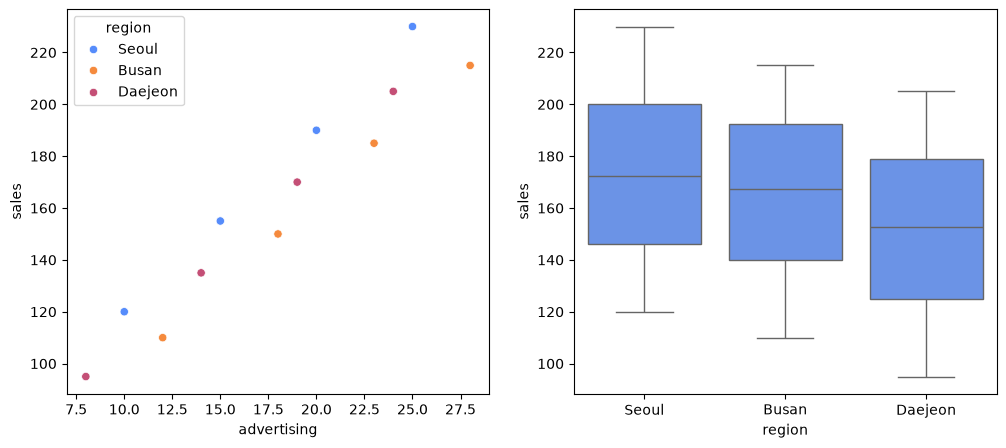

In [21]:
fig,axes=plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12,5),
)

sns.scatterplot(
    data=sales_df,
    x='advertising',
    y='sales',
    hue='region',
    ax=axes[0]    #첫번째 그래프에 들어감
)

sns.boxplot(    # 수염박스 그래프로 그려짐
    data=sales_df,
    x='region',
    y='sales',
    ax=axes[1]  #두번째 그래프에 들어감
)

plt.show()  # 여기까지는 axes 유형


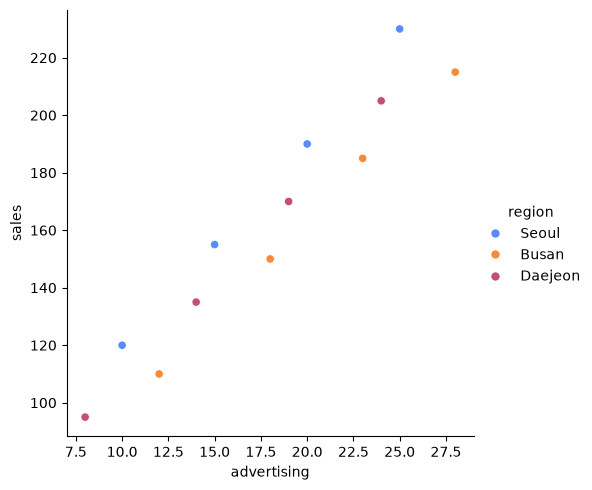

In [26]:
g = sns.relplot(    #relplot>관계형 그래프 의미,데이터의 관계를 나타내는 그래프
    data=sales_df,
    x='advertising',
    y='sales',
    hue='region',
    kind='scatter'
)

plt.show()

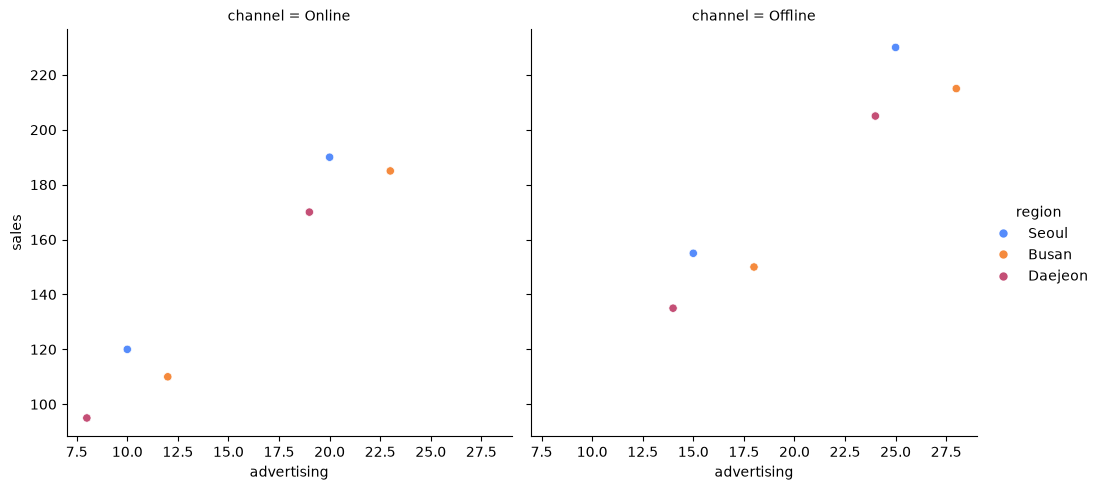

In [27]:
sns.relplot(
    data=sales_df,
    x='advertising',
    y='sales',
    hue='region',
    col='channel',
    kind='scatter'
)

plt.show()    # 관계 있는대로 묶일 수 있는 plot을 이용해서 column 기준으로 넣으면 알아서 된다. 범주형 데이터를 넣으면 그에 맞게 그래프를 그린다. 관계 있는 것을 열이나 범주로 묶어서 그래프로 > facet 방식

In [31]:
facet_df=sales_df.copy()

facet_df['period']= [
    'First','First','Second','Second',
    'First','First','Second','Second',
    'First','First','Second','Second',
]

In [32]:
facet_df[['region','channel','period']]

,region,channel,period
0,Seoul,Online,First
1,Seoul,Offline,First
2,Seoul,Online,Second
3,Seoul,Offline,Second
4,Busan,Online,First
5,Busan,Offline,First
6,Busan,Online,Second
7,Busan,Offline,Second
8,Daejeon,Online,First
9,Daejeon,Offline,First


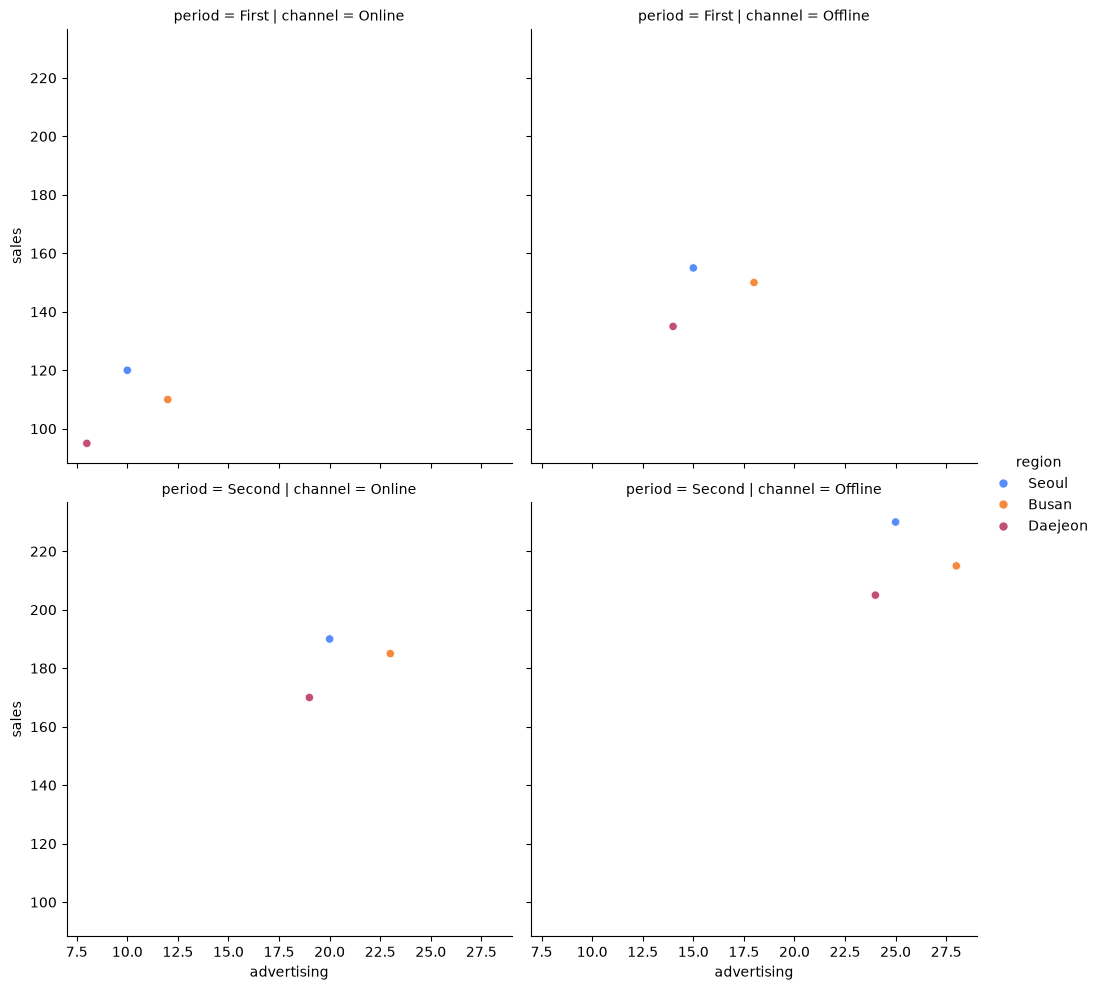

In [33]:
sns.relplot(
    data=facet_df,
    x='advertising',
    y='sales',
    hue='region',
    row = 'period',
    col='channel',
    kind='scatter'
)